###  Брахистохрона
Задача о нахождении кривой наискорейшего спуска, или *брахистохроны*, состоит в том, чтобы найти такую форму горки, чтобы время скатывания  по ней тела без трения было минимальным.

![SegmentLocal](https://upload.wikimedia.org/wikipedia/commons/6/63/Brachistochrone.gif)

Известно, что решение этой задачи - трансцедентная кривая, называемая [циклоидой](https://ru.wikipedia.org/wiki/%D0%A6%D0%B8%D0%BA%D0%BB%D0%BE%D0%B8%D0%B4%D0%B0). Кроме того, что это кривая минимизирует время спуска, она является траекторией точки на границе катящейся окружности, время спуска по этой кривой не зависит от начального положения, а еще маятник в часах имеет циклоидальный ограничитель, благодаря чему частота его колебаний не зависит от амплитуды.

Она была поставлена Иоганном Бернулли в 1696 году. Разные решения предлагали Исаак Ньютон, Якоб Бернулли, Г. В. Лейбниц, Г. Ф. Лопиталь, Э. В. Чирнхаус. Скорее всего, вы уже находили ее на курсе по вариационному исчислению, минимизируя значение какого-то там интеграла. Здесь же предлагается приблизить брахстохрону при помощи функционала scipy.optimize.

Самый простой способ построить брахистохрону - параметризовать ее (вывод формул из закона сохранения энергии можно найти [тут](https://en.wikipedia.org/wiki/Brachistochrone_curve#Indirect_method)
$$x = r \theta - r\sin \theta $$
$$y = r - r\cos  \theta$$

Т.е. мы хотим найти такие $\theta$ и $r$, что соответсвущая дуга циклоиды соединяет концы нашей горки.

**Как будем решать такую задачу?**

In [1]:
import numpy
import scipy
import matplotlib.pyplot as plt

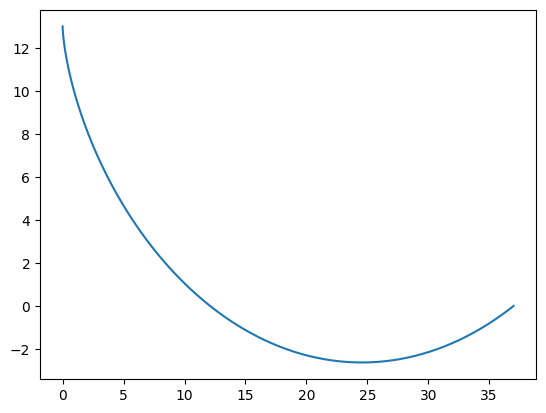

In [2]:
HEIGHT = 13
WIDTH = 37

fig = plt.figure()
ax = fig.add_subplot(111)

# WIDTH = r * (theta - sin(theta))
# HEIGHT = r * (1 - cos(theta))
# => r = HEIGHT / (1 - cos(theta))
# => WIDTH = HEIGHT * (theta - sin(theta)) / (1 - cos(theta))

def equation(theta):
    return WIDTH * (1 - numpy.cos(theta)) - HEIGHT * (theta - numpy.sin(theta))

theta = scipy.optimize.fsolve(equation, 3.0)[0]
r = HEIGHT / (1 - numpy.cos(theta))

ts = numpy.linspace(0, theta, 100)
sol_xs = r * (ts - numpy.sin(ts))
sol_ys = HEIGHT - r * (1 - numpy.cos(ts))

ax.plot(sol_xs, sol_ys)
fig.canvas.draw()
plt.show(block=False)

### Задача 3: Брахистохрона (1 балл)

В классе мы находили брахистохрону через параметризацию соответсвубщей дуги циклоиды. Ключевым здесь было то, что мы заранее знали, в каком виде искать ответ, что, к сожалению, далеко не всегда случается в реальной жизни. В этой задаче вам нужно будет построить кусочно-динейное приближение брахистохроны, не пользуясь явными формулами для ее формы. Другими словами, напишите функционал, который под данным высотам точек вычисляет время спуска, -- и минимизируйте этот функционал средствами scipy.

In [3]:
NUM_POINTS = 50
dx = WIDTH / (NUM_POINTS - 1)
xs = numpy.linspace(0, WIDTH, NUM_POINTS)

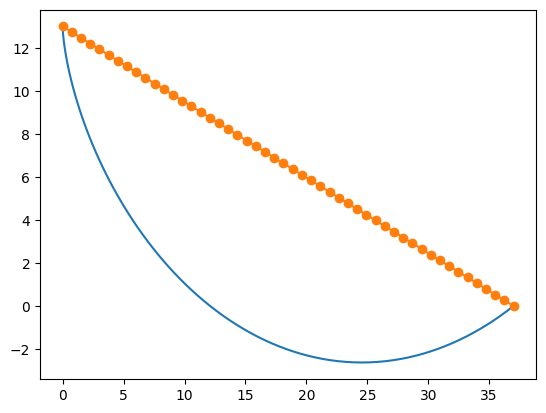

In [4]:
def draw(ys):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(sol_xs, sol_ys)
    (li,) = ax.plot(xs, ys, marker="o")

ys = numpy.linspace(HEIGHT, 0, NUM_POINTS)
draw(ys)

Закон сохранения энергии

$$ \dfrac{v_0^2}{2} + g h_0 = \dfrac{v_1^2}{2} + g h_1$$
$$ v_1 = \sqrt{v_0^2 + 2g(h_0 - h_1)}$$

In [5]:
def calc_one_period(x0, y0, x1, y1, v0):
    v1 = numpy.sqrt(v0 ** 2 + 2 * scipy.constants.g * (y0 - y1))

    dx = numpy.abs(x1 - x0)
    dy = numpy.abs(y1 - y0)
    s = numpy.sqrt(dx ** 2 + dy ** 2)
    cos = dy / s
    a = scipy.constants.g * cos

    time = numpy.abs(v1 - v0) / a
    return time, v1

def get_time(ys):
    cur_speed = 0
    total_time = 0
    for i in range(len(xs) - 1):
        time, new_speed = calc_one_period(xs[i], ys[i], xs[i + 1], ys[i + 1], cur_speed)
        total_time += time
        cur_speed = new_speed
    return total_time

get_time(ys)

np.float64(4.912031595300622)

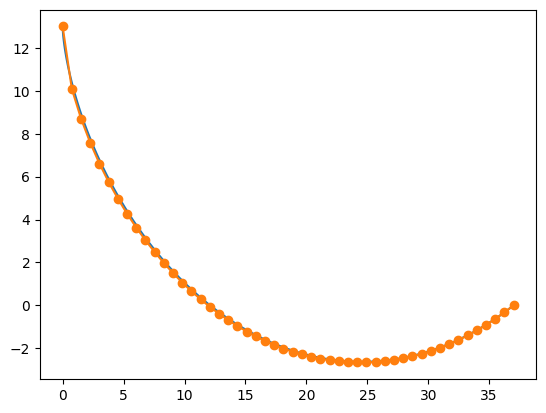

In [6]:
# Bounds: we can not move the first and the last points
bounds = (
    [(HEIGHT, HEIGHT)]
    + [(-float("inf"), float("inf")) for _ in range(NUM_POINTS - 2)]
    + [(0, 0)]
)

result = scipy.optimize.minimize(get_time, ys, method = 'L-BFGS-B', bounds = bounds)
draw(result.x)

In [7]:
get_time(ys), get_time(result.x)

(np.float64(4.912031595300622), np.float64(3.566081615329881))